In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns = None
import warnings

In [3]:
# 1 A)
df = pd.read_csv('/kaggle/input/customer-purchasing-behaviors/Customer Purchasing Behaviors.csv')
num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

data_types = df.dtypes
print("\ndata tyes of each column:")
print(data_types)

categorical_vars = df.select_dtypes(include=['object','category']).columns.tolist()
continuous_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("\categorical variables:", categorical_vars)
print("Continuous variables:", continuous_vars)

Number of rows: 238
Number of columns: 7

data tyes of each column:
user_id                 int64
age                     int64
annual_income           int64
purchase_amount         int64
loyalty_score         float64
region                 object
purchase_frequency      int64
dtype: object
\categorical variables: ['region']
Continuous variables: ['user_id', 'age', 'annual_income', 'purchase_amount', 'loyalty_score', 'purchase_frequency']


In [4]:
# 1 B)
numerical_columns = df.select_dtypes(include=['float64','int64']).columns
five_point_summary = df[numerical_columns].describe(percentiles=[0.25,0.5,0.75])
print(five_point_summary.loc[['min','25%','50%','75%','max']])

     user_id    age  annual_income  purchase_amount  loyalty_score  \
min     1.00  22.00        30000.0            150.0          3.000   
25%    60.25  31.00        50000.0            320.0          5.500   
50%   119.50  39.00        59000.0            440.0          7.000   
75%   178.75  46.75        66750.0            527.5          8.275   
max   238.00  55.00        75000.0            640.0          9.500   

     purchase_frequency  
min                10.0  
25%                17.0  
50%                20.0  
75%                23.0  
max                28.0  


In [7]:
# 1 C)
categorical_columns = df.select_dtypes(include=['object','category']).columns

for col in categorical_columns:
    print(F"Summary of categorical variable:{col}")
    
    num_categories = df[col].nunique()
    print(F"Number of categories: {num_categories}")
    
    category_counts = df[col].value_counts(normalize=True)*100
    print("Percenatge of observations in each category:")
    print(category_counts.to_string())

Summary of categorical variable:region
Number of categories: 4
Percenatge of observations in each category:
region
North    32.773109
South    32.352941
West     32.352941
East      2.521008


In [10]:
# 1 D)

missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values>0])
print("\n")

numerical_vars = df.select_dtypes(include=['int64','float64'])

print("Outliers detection (using IQR method):")
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+ 1.5*IQR
    outliers = df[(df[col] < lower_bound) | (df[col]> upper_bound)]
    print(F"Columns '{col}' - number of outliers : {outliers.shape[0]}")
print("\n")

age = 'age'
if age in df.columns:
    class_distribution = df[age].value_counts(normalize=True)*100
    print("Class distribution in age variable:")
    print(class_distribution)
    print("\n")

Missing values in each column:
Series([], dtype: int64)


Outliers detection (using IQR method):
Columns 'user_id' - number of outliers : 0
Columns 'age' - number of outliers : 0
Columns 'annual_income' - number of outliers : 0
Columns 'purchase_amount' - number of outliers : 0
Columns 'loyalty_score' - number of outliers : 0
Columns 'purchase_frequency' - number of outliers : 0


Class distribution in age variable:
age
33    5.882353
24    5.882353
41    5.882353
50    5.882353
29    3.781513
31    3.781513
37    3.361345
52    3.361345
26    3.361345
46    3.361345
40    3.361345
39    3.361345
49    3.361345
30    3.361345
38    3.361345
28    3.361345
27    3.361345
36    3.361345
45    3.361345
32    3.361345
43    2.941176
55    2.941176
48    2.941176
51    2.941176
54    2.941176
42    2.941176
34    0.840336
25    0.840336
47    0.420168
35    0.420168
44    0.420168
23    0.420168
22    0.420168
53    0.420168
Name: proportion, dtype: float64




In [8]:
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [11]:
# 2 A)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

numerical_vars = df.select_dtypes(include=['int64','float64'])
imputer = SimpleImputer(strategy='mean')
df[numerical_vars.columns] = imputer.fit_transform(numerical_vars)

categorical_vars = df.select_dtypes (include=['object','category'])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_vars.columns] = imputer_cat.fit_transform(categorical_vars)

print("Missing values hannlded.")
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df[col] = np.clip(df[col], lower_bound,upper_bound)
print("Outliers handled using capping.")

Missing values hannlded.
Outliers handled using capping.


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


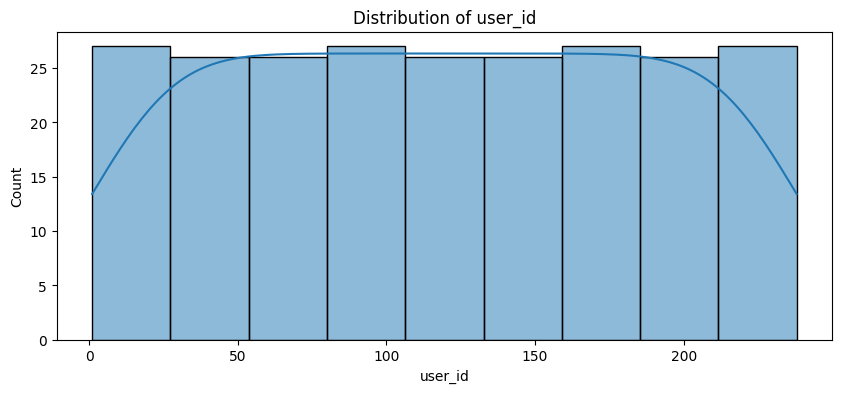

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


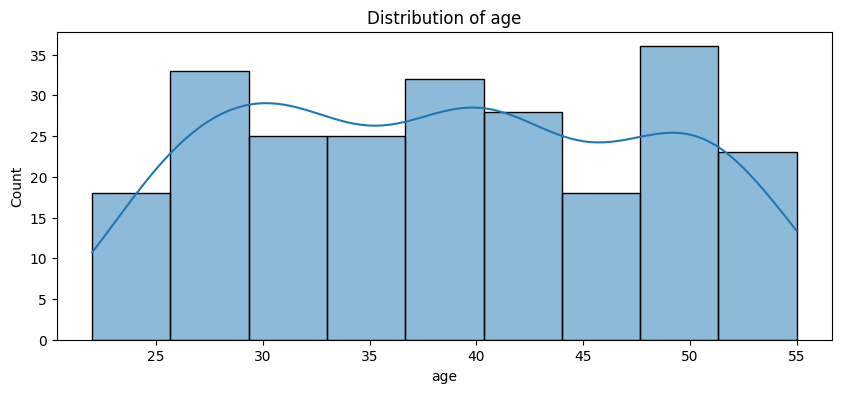

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


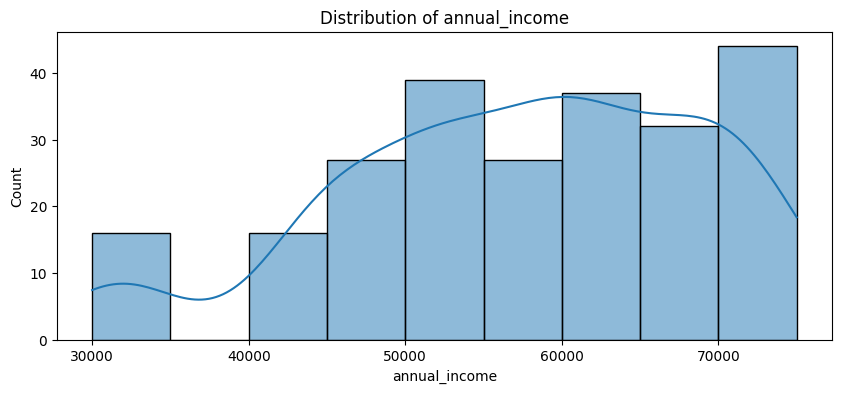

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


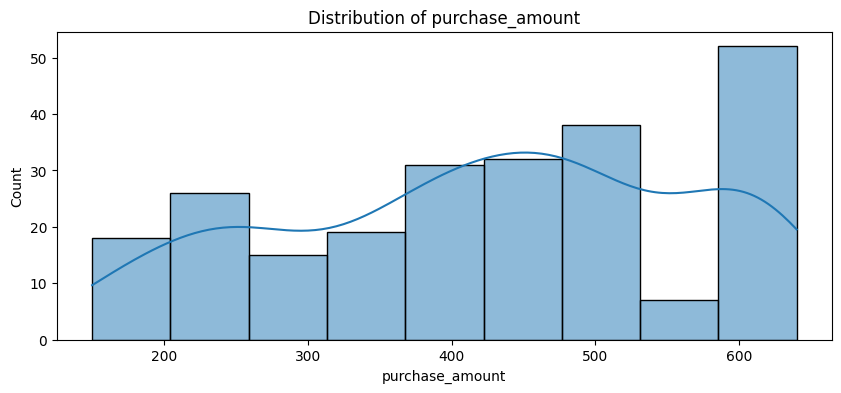

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


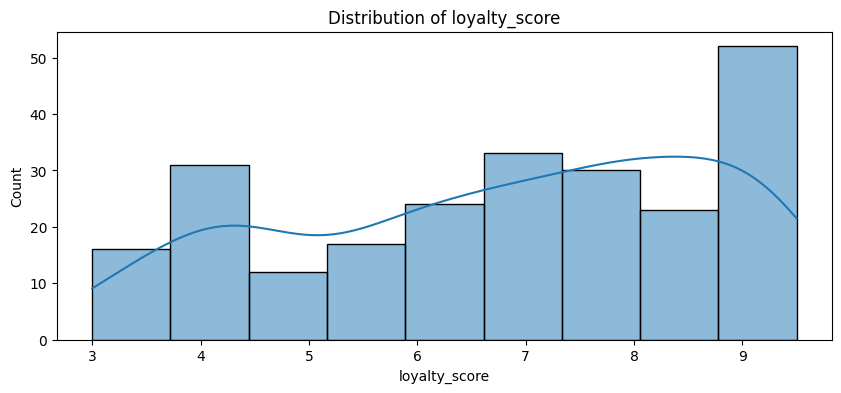

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


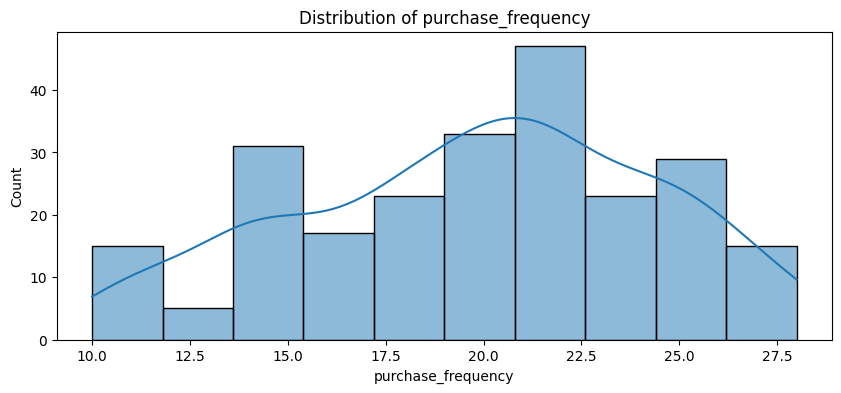

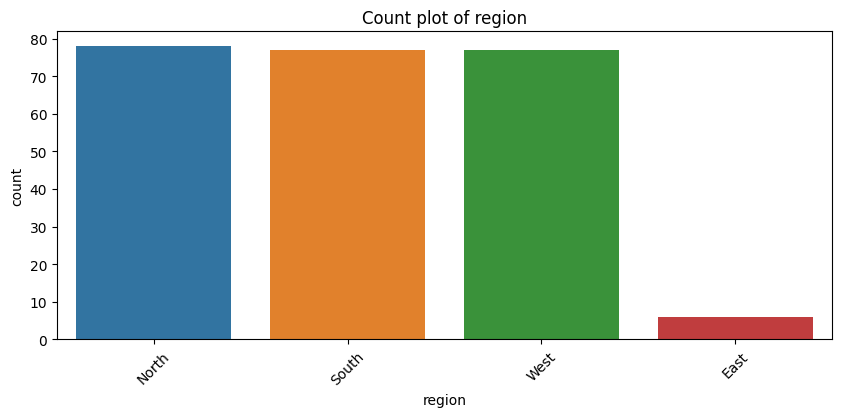

Correlation with age variable:
purchase_amount       0.986140
loyalty_score         0.981835
purchase_frequency    0.980532
annual_income         0.974833
user_id               0.067061
Name: age, dtype: float64


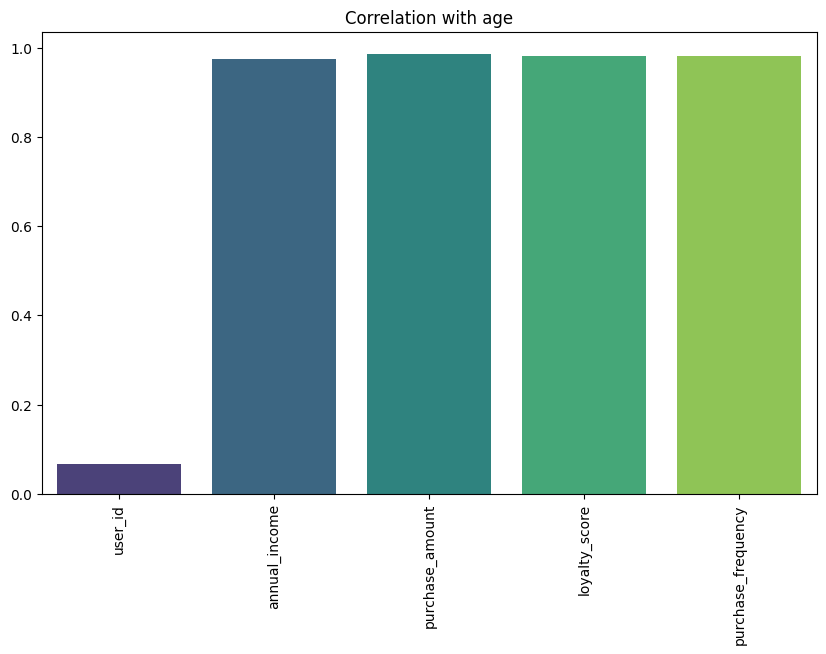

In [22]:
# 2 B)
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
    
categorical_vars = df.select_dtypes(include=['object','category'])
for col in categorical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(f"Count plot of {col}")
    plt.xticks(rotation=45)
    plt.show()
    
age = 'age'
if age in df.columns:
    df_numerical = df.select_dtypes(include=['int64','float64'])
    correlations = df_numerical.corr()[age].drop(age)
    
    print("Correlation with age variable:")
    print(correlations.sort_values(ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(x=correlations.index,y=correlations.values,palette='viridis')
    plt.title(f"Correlation with {age}")
    plt.xticks(rotation=90)
    plt.show()

In [26]:
# 2 C)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

variables_to_exclude = ['region','age']
df_cleaned = df.drop(columns=variables_to_exclude)

age = 'age'
if age in df_cleaned.columns:
    x = df_cleaned.drop(columns=[age])
    y = df_cleaned[age]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    
    scaler = StandardScaler()
    numerical_features = x_train.select_dtypes(include=['int64','float64']).columns
    x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
    x_test[numerical_features] = scaler.transform(x_test[numerical_features])
    
    print("Data preparation complete.the dataset is now ready for model creation.")

In [30]:
# 2 D)
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_vars = df.select_dtypes(include=['object','category']).columns

label_encoders = {}
for col in categorical_vars:
    le=LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    
    print("Label encoding completed.")
    
    df_encoded = pd.get_dummies(df,columns=categorical_vars,drop_first=True)
    print("One-Hot Encoding completed.")
    
    preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='First'), categorical_vars)
        
    ],
    remainder='passthrough')
    
    x= preprocessor.fit_transform(df)
    print("ColumnTransform Completed.")

In [41]:
# 2 E)
from sklearn.model_selection import train_test_split
from scipy import stats

age = 'age'
if age in df.columns:
    x = df.drop(columns=[age])
    y=df[age]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    def compare_distributions (df1,df2,columns):
        for col in columns:
            if df1[col].dtype in ['int64','float64']:
                _,p_value = stats.ks_2samp(df1[col],df2[col])
                print(F"Kolmogorov-SMirnov test p-value for {col}: {p_value:.4f}")
                
                if p_value <0.05:
                    
                    print(f"Distribution of {col} is significantly different between training and testing sets.")
                else:
                    print(f"Distribution of {col} is similar between training and testing sets.")
            else:
                contingency = pd.crosstab(df1[col], df2[col])
                _,p_value, _,_ = stats.chi2_contingency(contingency)
                print(F"Chi-square test p-value for {col}: {p_value:.4f}")
                if p_value< 0.05:
                    print(f"Distribution of {col} is significantly different between training and testing sets.")
                else:
                    print(f"Distribution of {col} is similar between training and testing sets.")
    compare_distributions(pd.concat([x_train,y_train],axis=1), pd.concat([x_test,y_test],axis=1),x.columns)

Kolmogorov-SMirnov test p-value for user_id: 0.6646
Distribution of user_id is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for annual_income: 0.8974
Distribution of annual_income is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for purchase_amount: 0.8974
Distribution of purchase_amount is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for loyalty_score: 0.7083
Distribution of loyalty_score is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for region: 0.9980
Distribution of region is similar between training and testing sets.
Kolmogorov-SMirnov test p-value for purchase_frequency: 0.9409
Distribution of purchase_frequency is similar between training and testing sets.


In [43]:
# 3 A)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

age = 'age'
if age in df.columns:
    x=df.drop(columns=[age])
    y=df[age]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(F"Mean squared error of linear regression model: {mse:.4f}")
    print(F"R2 score of linear regression model: {r2:.4f}")
    
 # Key Obseravtions:
# 1) Linear regression : a fundamental regression technique that models the relationship between dependent amd independent variables linearly.
# 2) Baseline Performance:Model servae as a baseline to evaluate more complex algorithims they help establish a performance between.
# 3) Interpretability: coefficients represent the effect of each feature on the age variable,providong clear insight into relationship within the data.
# 4) Compuatational efficiency: model are computationally efficient and require less computational power
#    compared to more complex models, making them ideal for inital explorations.
# 5) For Regression: Mean squared error(MSE) indicate the average squared different between predicted and actual values .lower MSe signifies better model performance.
# 6) R^2 scores: Represents the proportion of variance explained by the model. A higher R^2 value indicates a better fit to the data.


Mean squared error of linear regression model: 2.6885
R2 score of linear regression model: 0.9719


In [46]:
# 3 B)
from sklearn.metrics import accuracy_score

y_true = [0,1,1,0,1,0,1,1,0,0]
y_pred = [0,1,0,0,1,0,1,0,0,1]
accuracy = accuracy_score(y_true,y_pred)

print(F"Overall accuracy: {accuracy:.2f}")

if accuracy>=0.80:
    print("The accuracy is good.the model is performing well.")
elif 0.60 <=accuracy <0.80:
    print("The accuracy is moderate, the model may need improvement.")
else:
    print("The accuracy is low.The model requires significant improvements.")
    
# Key Observation:
# 1) Accuracy Calculation : the accuarcy score function compare the true labels (y_true) with the predicted labels (y_pred) and calculate the proportion of correct predictions.
# 2) Commentary on accuracy: The code include conditional statement to provide a basic evaluation of the accuracy.
# Good Accuracy(>80%) : indicates that the model is performing well.
# Moderate Accuracy(60% to 80%) : Suggests that there  may be room for improvement.
# Low accuracy(>60%): Indicate that the model's performance is poor,and  significant adjustment or different approaches might be needed.

    

Overall accuracy: 0.70
The accuracy is moderate, the model may need improvement.


In [49]:
# 3 C)
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

data = load_iris()
x = data.data
y = data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

precision = precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')

print("Precision:", precision)
print("Recall", recall)
print("F1 scaore", f1)

print("\nclassification Report:")
print(classification_report(y_test,y_pred))

# Key Obseravtions:
# 1) Precision: Is the ratio of correlcty predicted positive observation to the total predicted positives.
#               it is useful when the cpst of flase positive is high.
# 2) Recall: (Alos known as sensitivity) is the ratio of correlctlt predicted positive observation to all
# Obseravtion in the actual class. it is important when the cost of false negative is high.

# 3) F1 score: Is the harmonic mean of precision and recall it is a good metric when you need a balance
#  between precision and recall and there is an uneven class distribution.

# 4) Choosing the right metric depend on the problem statement: If flase positive are costly (eg,email,spam detection)prioritize precision.
# If false negative are costly(eg., medical daignoses),prioritize recall.
# If you need a balance or if the classes are imbalanced, use F1 score.


Precision: 1.0
Recall 1.0
F1 scaore 1.0

classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [55]:
# 3 D)
from sklearn.datasets import load_iris
from sklearn.model_selection import  train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

data = load_iris()
x = data.data
y=data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [50,100,200],
    'model__max_depth': [None,10,20,30]
}

grid_search = GridSearchCV(pipeline,param_grid,cv=5,scoring='accuracy')
grid_search.fit(x_train,y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nBest parameters:",grid_search.best_params_)

# Key Observations:
# 1)Data Preprocessing : added fetaure scaling using standardscaler
# 2) Model selection : Use a pipeline to combine scaling and model training  implemet Gridsearchcv to find optimal hyperparametrs for randomforestclassifier.
# 3) Cross Validation: Include cross validation i  gridSearchCV  to ensure the model generalize well.
# 4) By following these steps , you shuld see an improvement in the accuracy of your model.adjustments to hyperparametrs,preprocessing and model choice shuld be based on the specific characteristics of your datset and problem.


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Best parameters: {'model__max_depth': None, 'model__n_estimators': 50}


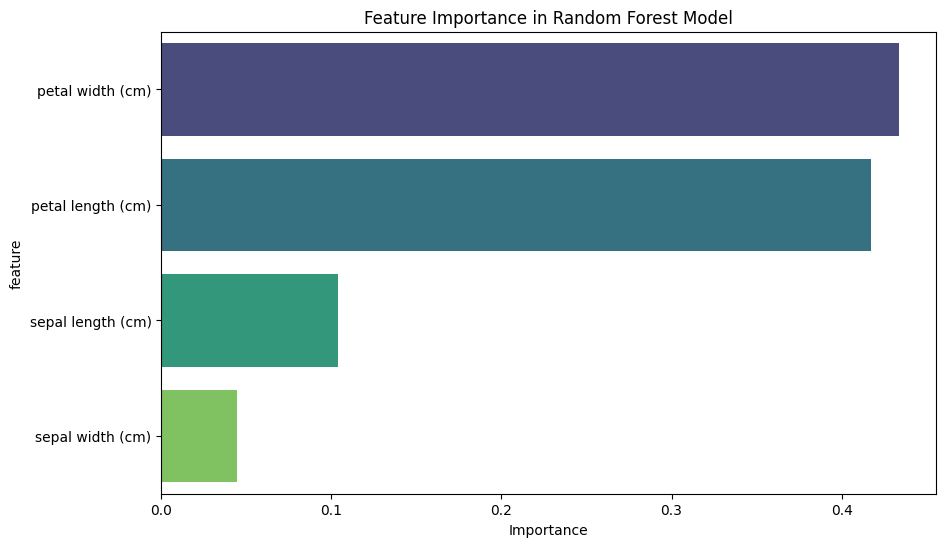

In [60]:
# E)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_iris()
x = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_tain)

feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature':x.columns,
    'Importance': feature_importances
    
}).sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='feature',data=feature_importance_df,palette='viridis')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('feature')
plt.show()

# Key Observations:
# Bussiness Interpretion of the model
#1) Top features Affecting the target : The bar chart deisplay the most important fetaures influencing the target variables.
# In this example using the iris dataset. feature like "petal length (CM)" and "Petal width (CM)" have the highest importance.
# indicating they are the most influential in predicting the target variable(Species if the flower).

# 2) Understanding Feature Relationship : the relationship between the fetaure and the target can be further understood
# Using additional plots such as partial dependence plots or shap vaues,for example,if "Petal length" has the highest
# Importance, we might examine how changes in petal length impact the predicted probability of different flower species.